In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define path to the pre-processed SMARD dataset
file_path = (
    "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
)

# Verify file existence
if os.path.exists(file_path):
  print("Dataset found successfully! Proceeding with data loading...")
else:
  print(
      "File not found! Please verify the folder structure in your Google Drive."
  )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found successfully! Proceeding with data loading...


 20 MW PEM ELECTROLYZER LCOH DISPATCH OPTIMIZATION BENCHMARK
Optimal Grid Electricity Threshold:  €65 / MWh
Optimal Operating Full Load Hours:    8642 Hours/Year (98.7% Capacity Factor)
Annual Green Hydrogen Production:     3,099.3 Tonnes H2 / year
Minimum Levelized Cost (LCOH):        €3.35 / kg H2
---------------------------------------------------------------------------
LCOH Cost Breakdown:
  • Electricity Cost:                €2.25 / kg (67.0%)
  • CAPEX Depreciation:              €0.67 / kg (20.0%)
  • Fixed OPEX & Stack Replacement:  €0.41 / kg (12.1%)
  • Water & Feedstock:               €0.03 / kg (0.9%)


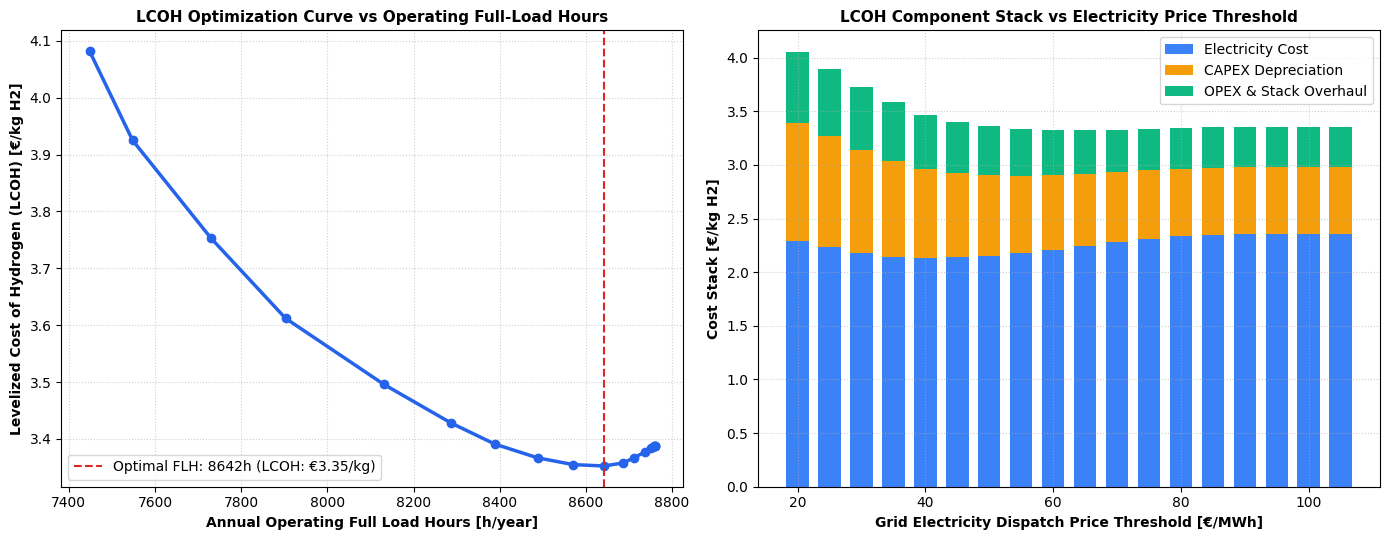

Data exported successfully as 'green_hydrogen_lcoh_optimization_2026.csv'


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================================
# 1. PEM ELECTROLYZER & CO-LOCATED HYBRID ASSET PARAMETERS
# ==========================================================
ELECTROLYZER_CAP_MW = 20.0  # 20 MW Rated PEM Electrolyzer Plant
PEM_SPECIFIC_CONSUMPTION = (
    52.5  # kWh electricity / kg H2 produced (52.5 MWh/tonne)
)
MIN_LOAD_FRACTION = 0.10  # 10% minimum turndown load (2 MW)
WIND_CAP_MW = 30.0  # 30 MW Onshore Wind Farm
SOLAR_CAP_MW = 20.0  # 20 MW Solar PV Plant

# Financial Parameters (CAPEX, OPEX, Stack Replacement, WACC)
CAPEX_EUR_PER_KW = 1100.0  # €1,100 / kW turnkey installed
TOTAL_CAPEX_EUR = (
    ELECTROLYZER_CAP_MW * 1000 * CAPEX_EUR_PER_KW
)  # €22,000,000 CAPEX
ANNUAL_FIXED_OPEX_EUR = TOTAL_CAPEX_EUR * 0.03  # 3% of CAPEX (€660k/yr)
STACK_LIFETIME_HOURS = 60000  # Stack overhaul every 60,000 operating hours
STACK_REPLACEMENT_COST_EUR = (
    ELECTROLYZER_CAP_MW * 1000 * 300.0
)  # €6,000,000 per stack overhaul
WATER_COST_EUR_PER_KG = 0.03  # €0.03/kg H2 demineralized water
WACC = 0.07  # 7% Discount rate
PROJECT_LIFETIME_YEARS = 20  # 20-Year plant economic life
RE_PPA_PRICE_EUR_MWH = 45.0  # Fixed corporate PPA cost for on-site wind/solar

# ==========================================================
# 2. 8,760-HOUR SIMULATION (RENEWABLE GENERATION & POWER SPOT)
# ==========================================================
np.random.seed(42)
hours = np.arange(8760)
dates = pd.date_range(start="2026-01-01 00:00:00", periods=8760, freq="h")
dayofyear = dates.dayofyear.to_numpy()
hourofday = dates.hour.to_numpy()

# Solar PV Profile (Seasonal & Diurnal)
solar_seasonal = np.sin((dayofyear / 365) * np.pi) ** 2
solar_diurnal = np.maximum(0, np.sin((hourofday - 5) * np.pi / 14))
solar_gen_mw = np.round(
    SOLAR_CAP_MW
    * solar_seasonal
    * solar_diurnal
    * np.random.uniform(0.7, 1.05, 8760),
    2,
)

# Wind Profile (Synoptic wind variability)
wind_seasonal = 0.6 + 0.4 * np.cos((dayofyear / 365) * 2 * np.pi)
wind_synoptic = np.clip(
    np.sin(hours / 72 * np.pi) + np.random.normal(0, 0.4, 8760), -0.8, 1.0
)
wind_cf = np.clip((wind_synoptic + 0.8) / 1.8 * wind_seasonal, 0.05, 0.95)
wind_gen_mw = np.round(WIND_CAP_MW * wind_cf, 2)
total_re_gen_mw = solar_gen_mw + wind_gen_mw

# Day-Ahead Power Prices (€/MWh)
base_power_price = (
    55.0
    + 25.0 * np.sin((hourofday - 4) * np.pi / 12)
    - (total_re_gen_mw / 50.0) * 45.0
    + np.random.normal(0, 8, 8760)
)
power_price_eur_mwh = np.round(np.clip(base_power_price, -25.0, 180.0), 2)

# ==========================================================
# 3. DISPATCH OPTIMIZATION & LCOH THRESHOLD SWEEPER
# ==========================================================
THRESHOLDS = np.arange(20, 110, 5)  # Grid dispatch threshold (€/MWh)
threshold_results = []

crf = (WACC * (1 + WACC) ** PROJECT_LIFETIME_YEARS) / (
    (1 + WACC) ** PROJECT_LIFETIME_YEARS - 1
)
annualized_capex = TOTAL_CAPEX_EUR * crf

for thresh in THRESHOLDS:
  h2_produced_kg_hourly = []
  elec_cost_hourly = []
  operating_hours = 0

  for h in range(8760):
    grid_p = power_price_eur_mwh[h]
    re_p = total_re_gen_mw[h]

    if grid_p <= thresh or re_p >= (
        ELECTROLYZER_CAP_MW * MIN_LOAD_FRACTION
    ):
      operating_hours += 1
      if re_p >= ELECTROLYZER_CAP_MW:
        p_used_re = ELECTROLYZER_CAP_MW
        p_used_grid = 0.0
        cost = p_used_re * RE_PPA_PRICE_EUR_MWH
      else:
        p_used_re = re_p
        if grid_p <= thresh:
          p_used_grid = ELECTROLYZER_CAP_MW - p_used_re
          cost = (p_used_re * RE_PPA_PRICE_EUR_MWH) + (p_used_grid * grid_p)
        else:
          p_used_grid = 0.0
          cost = p_used_re * RE_PPA_PRICE_EUR_MWH

      p_total = p_used_re + p_used_grid
      if p_total < (ELECTROLYZER_CAP_MW * MIN_LOAD_FRACTION):
        p_total = 0.0
        cost = 0.0
        operating_hours -= 1
    else:
      p_total = 0.0
      cost = 0.0

    h2_kg = (p_total * 1000.0) / PEM_SPECIFIC_CONSUMPTION
    h2_produced_kg_hourly.append(h2_kg)
    elec_cost_hourly.append(cost)

  annual_h2_kg = sum(h2_produced_kg_hourly)
  annual_elec_cost = sum(elec_cost_hourly)
  annual_water_cost = annual_h2_kg * WATER_COST_EUR_PER_KG

  stack_replacements = int(
      (operating_hours * PROJECT_LIFETIME_YEARS) / STACK_LIFETIME_HOURS
  )
  annualized_stack = (
      stack_replacements * STACK_REPLACEMENT_COST_EUR
  ) / PROJECT_LIFETIME_YEARS

  total_annual_cost = (
      annualized_capex
      + ANNUAL_FIXED_OPEX_EUR
      + annualized_stack
      + annual_elec_cost
      + annual_water_cost
  )
  lcoh_eur_kg = total_annual_cost / (annual_h2_kg + 1e-6)

  threshold_results.append({
      "threshold_eur_mwh": thresh,
      "full_load_hours": operating_hours,
      "annual_h2_tonnes": annual_h2_kg / 1000.0,
      "lcoh_eur_kg": lcoh_eur_kg,
      "capex_per_kg": annualized_capex / annual_h2_kg,
      "opex_per_kg": (ANNUAL_FIXED_OPEX_EUR + annualized_stack) / annual_h2_kg,
      "elec_per_kg": annual_elec_cost / annual_h2_kg,
      "water_per_kg": annual_water_cost / annual_h2_kg,
  })

df_lcoh = pd.DataFrame(threshold_results)
opt_idx = df_lcoh["lcoh_eur_kg"].idxmin()
opt_case = df_lcoh.loc[opt_idx]

print("=" * 75)
print(" 20 MW PEM ELECTROLYZER LCOH DISPATCH OPTIMIZATION BENCHMARK")
print("=" * 75)
print(
    "Optimal Grid Electricity Threshold: "
    f" €{opt_case['threshold_eur_mwh']:.0f} / MWh"
)
print(
    f"Optimal Operating Full Load Hours:    {opt_case['full_load_hours']:.0f}"
    f" Hours/Year ({opt_case['full_load_hours']/8760*100:.1f}% Capacity"
    " Factor)"
)
print(
    "Annual Green Hydrogen Production:    "
    f" {opt_case['annual_h2_tonnes']:,.1f} Tonnes H2 / year"
)
print(
    "Minimum Levelized Cost (LCOH):       "
    f" €{opt_case['lcoh_eur_kg']:.2f} / kg H2"
)
print("-" * 75)
print("LCOH Cost Breakdown:")
print(
    f"  • Electricity Cost:                €{opt_case['elec_per_kg']:.2f} /"
    f" kg ({opt_case['elec_per_kg']/opt_case['lcoh_eur_kg']*100:.1f}%)"
)
print(
    f"  • CAPEX Depreciation:              €{opt_case['capex_per_kg']:.2f} /"
    f" kg ({opt_case['capex_per_kg']/opt_case['lcoh_eur_kg']*100:.1f}%)"
)
print(
    "  • Fixed OPEX & Stack Replacement: "
    f" €{opt_case['opex_per_kg']:.2f} /"
    f" kg ({opt_case['opex_per_kg']/opt_case['lcoh_eur_kg']*100:.1f}%)"
)
print(
    f"  • Water & Feedstock:               €{opt_case['water_per_kg']:.2f} /"
    f" kg ({opt_case['water_per_kg']/opt_case['lcoh_eur_kg']*100:.1f}%)"
)
print("=" * 75)

# ==========================================================
# 4. VISUALIZATION & EXPORT
# ==========================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Plot 1: LCOH Curve vs Operating Hours
ax1.plot(
    df_lcoh["full_load_hours"],
    df_lcoh["lcoh_eur_kg"],
    color="#2563EB",
    lw=2.5,
    marker="o",
)
ax1.axvline(
    opt_case["full_load_hours"],
    color="#DC2626",
    linestyle="--",
    lw=1.5,
    label=(
        f"Optimal FLH: {opt_case['full_load_hours']:.0f}h (LCOH:"
        f" €{opt_case['lcoh_eur_kg']:.2f}/kg)"
    ),
)
ax1.set_title(
    "LCOH Optimization Curve vs Operating Full-Load Hours",
    fontweight="bold",
    fontsize=11,
)
ax1.set_xlabel(
    "Annual Operating Full Load Hours [h/year]", fontweight="bold"
)
ax1.set_ylabel(
    "Levelized Cost of Hydrogen (LCOH) [€/kg H2]", fontweight="bold"
)
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend()

# Plot 2: Cost Stack vs Grid Price Threshold
ax2.bar(
    df_lcoh["threshold_eur_mwh"],
    df_lcoh["elec_per_kg"],
    width=3.5,
    label="Electricity Cost",
    color="#3B82F6",
)
ax2.bar(
    df_lcoh["threshold_eur_mwh"],
    df_lcoh["capex_per_kg"],
    width=3.5,
    bottom=df_lcoh["elec_per_kg"],
    label="CAPEX Depreciation",
    color="#F59E0B",
)
ax2.bar(
    df_lcoh["threshold_eur_mwh"],
    df_lcoh["opex_per_kg"],
    width=3.5,
    bottom=df_lcoh["elec_per_kg"] + df_lcoh["capex_per_kg"],
    label="OPEX & Stack Overhaul",
    color="#10B981",
)
ax2.set_title(
    "LCOH Component Stack vs Electricity Price Threshold",
    fontweight="bold",
    fontsize=11,
)
ax2.set_xlabel(
    "Grid Electricity Dispatch Price Threshold [€/MWh]", fontweight="bold"
)
ax2.set_ylabel("Cost Stack [€/kg H2]", fontweight="bold")
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.savefig("green_hydrogen_lcoh_dispatch_optimization.png", dpi=300)
plt.show()

# Export Data
df_lcoh.to_csv("green_hydrogen_lcoh_optimization_2026.csv", index=False)
print("Data exported successfully as 'green_hydrogen_lcoh_optimization_2026.csv'")